In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import json
import clip
import os
import pickle
import faiss
from pathlib import Path
from PIL import Image
from transformers import DistilBertTokenizer, DistilBertModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Paths
IMAGE_DIR     = Path(r"E:\Rohanta_AI_workbook\campus_chatbot\data\images")
KB_PATH       = r"E:\Rohanta_AI_workbook\campus_chatbot\data\campus_kb.json"
DISTILBERT_DIR= Path(r"E:\Rohanta_AI_workbook\campus_chatbot\models\distilbert_campus")
FAISS_DIR     = Path(r"E:\Rohanta_AI_workbook\campus_chatbot\models\clip_faiss")
MLP_DIR       = Path(r"E:\Rohanta_AI_workbook\campus_chatbot\models\fusion_mlp")
MLP_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cpu")

# Load KB
with open(KB_PATH, encoding="utf-8") as f:
    kb = json.load(f)
kb_lookup = {entry["name"]: entry for entry in kb}

print("Imports done")
print(f"Device: {DEVICE}")

e:\Rohanta_AI_workbook\campus_chatbot\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports done
Device: cpu


In [2]:
# Load CLIP
clip_model, clip_preprocess = clip.load("ViT-B/32", device=DEVICE)
clip_model.eval()
print("CLIP loaded")

# Load DistilBERT for embeddings (base model, not classifier)
db_tokenizer  = DistilBertTokenizer.from_pretrained(DISTILBERT_DIR)
db_base_model = DistilBertModel.from_pretrained("distilbert-base-uncased").to(DEVICE)
db_base_model.eval()
print("DistilBERT loaded")

# Category to KB mapping
CATEGORY_TO_KB = {
    "library":       "Main Library",
    "cafeteria":     "Main Cafeteria",
    "lecture_hall":  "Main Auditorium",
    "gym":           "Sports & Fitness Centre",
    "it_lab":        "IT & Computer Lab",
    "lab":           "IT & Computer Lab",
    "admin_office":  "Admissions & Registry Office",
    "outdoor":       "Campus Garden & Outdoor Study Area",
    "auditorium":    "Main Auditorium",
    "student_union": "Student Union",
    "career_center": "Career Services Centre",
    "medical_center":"Medical & Counselling Centre",
    "engineering":   "Engineering College - Main Block",
}

# Unique KB locations (13 classes)
KB_CLASSES = sorted(set(CATEGORY_TO_KB.values()))
CLASS_TO_IDX = {c: i for i, c in enumerate(KB_CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

print(f"\n13 classes:")
for i, c in IDX_TO_CLASS.items():
    print(f"  {i:2d} → {c}")

CLIP loaded


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 860.10it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT loaded

13 classes:
   0 → Admissions & Registry Office
   1 → Campus Garden & Outdoor Study Area
   2 → Career Services Centre
   3 → Engineering College - Main Block
   4 → IT & Computer Lab
   5 → Main Auditorium
   6 → Main Cafeteria
   7 → Main Library
   8 → Medical & Counselling Centre
   9 → Sports & Fitness Centre
  10 → Student Union


In [3]:
from tqdm import tqdm

def get_clip_embedding(image_path: str) -> np.ndarray:
    image = clip_preprocess(
        Image.open(image_path).convert("RGB")
    ).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        emb = clip_model.encode_image(image)
        emb = emb / emb.norm(dim=-1, keepdim=True)
    return emb.cpu().numpy().squeeze()


def get_distilbert_embedding(text: str) -> np.ndarray:
    encoding = db_tokenizer(
        text,
        max_length     = 64,
        padding        = "max_length",
        truncation     = True,
        return_tensors = "pt",
    )
    with torch.no_grad():
        output = db_base_model(
            input_ids      = encoding["input_ids"].to(DEVICE),
            attention_mask = encoding["attention_mask"].to(DEVICE),
        )
        cls_emb = output.last_hidden_state[:, 0, :]
        cls_emb = cls_emb / cls_emb.norm(dim=-1, keepdim=True)
    return cls_emb.cpu().numpy().squeeze()


# Build dataset
print("Extracting embeddings...")
data = []

for cat in sorted(os.listdir(IMAGE_DIR)):
    cat_path = IMAGE_DIR / cat
    if not cat_path.is_dir():
        continue
    kb_name = CATEGORY_TO_KB.get(cat)
    if kb_name not in CLASS_TO_IDX:
        continue

    label      = CLASS_TO_IDX[kb_name]
    kb_entry   = kb_lookup.get(kb_name, {})
    kb_desc    = kb_entry.get("description", kb_name)

    # Text embedding from KB description
    text_emb = get_distilbert_embedding(kb_desc)

    for fname in tqdm(os.listdir(cat_path), desc=cat):
        if not fname.lower().endswith((".jpg",".jpeg",".png")):
            continue
        img_path = str(cat_path / fname)
        try:
            img_emb = get_clip_embedding(img_path)
            data.append({
                "image_emb": img_emb,   # 512-dim
                "text_emb":  text_emb,  # 768-dim
                "label":     label,
                "kb_name":   kb_name,
                "category":  cat,
            })
        except Exception as e:
            print(f"Error: {fname} — {e}")

print(f"\nTotal samples : {len(data)}")
print(f"Classes       : {len(set(d['label'] for d in data))}")
print(f"Image emb dim : {data[0]['image_emb'].shape}")
print(f"Text emb dim  : {data[0]['text_emb'].shape}")

Extracting embeddings...


student_union: 100%|██████████| 10/10 [00:02<00:00,  3.76it/s]


Total samples : 127
Classes       : 11
Image emb dim : (512,)
Text emb dim  : (768,)


In [4]:
# Concatenate image + text embeddings → 1280-dim fusion vector
X = np.array([
    np.concatenate([d["image_emb"], d["text_emb"]])
    for d in data
], dtype="float32")

y = np.array([d["label"] for d in data], dtype="int64")

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}")

# Train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain : {len(X_train)}")
print(f"Val   : {len(X_val)}")

# Dataset class
class FusionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = FusionDataset(X_train, y_train)
val_ds   = FusionDataset(X_val,   y_val)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False)

print(f"\nTrain batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

X shape : (127, 1280)
y shape : (127,)
Classes : [ 0  1  2  3  4  5  6  7  8  9 10]

Train : 101
Val   : 26

Train batches : 7
Val batches   : 2


In [5]:
class FusionMLP(nn.Module):
    def __init__(self, input_dim=1280, num_classes=11):
        super(FusionMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.network(x)

    def get_routing_vector(self, x):
        """Returns 128-dim routing vector before final classification layer."""
        for layer in list(self.network.children())[:-1]:
            x = layer(x)
        return x


model_mlp = FusionMLP(input_dim=1280, num_classes=11).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model_mlp.parameters())
print(f"MLP Architecture:")
print(model_mlp)
print(f"\nTotal parameters : {total_params:,}")
print(f"Input dim        : 1280 (512 CLIP + 768 DistilBERT)")
print(f"Output classes   : 11")

MLP Architecture:
FusionMLP(
  (network): Sequential(
    (0): Linear(in_features=1280, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=11, bias=True)
  )
)

Total parameters : 722,955
Input dim        : 1280 (512 CLIP + 768 DistilBERT)
Output classes   : 11


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_mlp.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

EPOCHS = 100

history = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  [],
}

print("Training Fusion MLP...\n")
print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<10}")
print("-" * 55)

for epoch in range(EPOCHS):

    # --- Train ---
    model_mlp.train()
    train_loss = train_correct = train_total = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model_mlp(X_batch)
        loss    = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item()
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == y_batch).sum().item()
        train_total   += y_batch.size(0)

    scheduler.step()

    # --- Validate ---
    model_mlp.eval()
    val_loss = val_correct = val_total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            outputs  = model_mlp(X_batch)
            loss     = criterion(outputs, y_batch)
            val_loss    += loss.item()
            preds        = outputs.argmax(dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total   += y_batch.size(0)

    t_loss = train_loss / len(train_loader)
    v_loss = val_loss   / len(val_loader)
    t_acc  = train_correct / train_total * 100
    v_acc  = val_correct   / val_total   * 100

    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["train_acc"].append(t_acc)
    history["val_acc"].append(v_acc)

    if (epoch + 1) % 10 == 0:
        print(f"{epoch+1:<8} {t_loss:<12.4f} {t_acc:<12.1f} {v_loss:<12.4f} {v_acc:.1f}%")

print("\nTraining complete!")
print(f"Best val accuracy: {max(history['val_acc']):.1f}% at epoch {history['val_acc'].index(max(history['val_acc']))+1}")

Training Fusion MLP...

Epoch    Train Loss   Train Acc    Val Loss     Val Acc   
-------------------------------------------------------
10       0.8577       88.1         0.8613       92.3%
20       0.0843       100.0        0.2041       96.2%
30       0.0436       100.0        0.1384       96.2%
40       0.0195       100.0        0.1194       96.2%
50       0.0161       100.0        0.1200       96.2%
60       0.0157       100.0        0.1150       96.2%
70       0.0198       100.0        0.1069       96.2%
80       0.0134       100.0        0.1118       96.2%
90       0.0135       100.0        0.1142       96.2%
100      0.0118       100.0        0.1060       96.2%

Training complete!
Best val accuracy: 96.2% at epoch 11


Model saved: E:\Rohanta_AI_workbook\campus_chatbot\models\fusion_mlp/fusion_mlp.pt


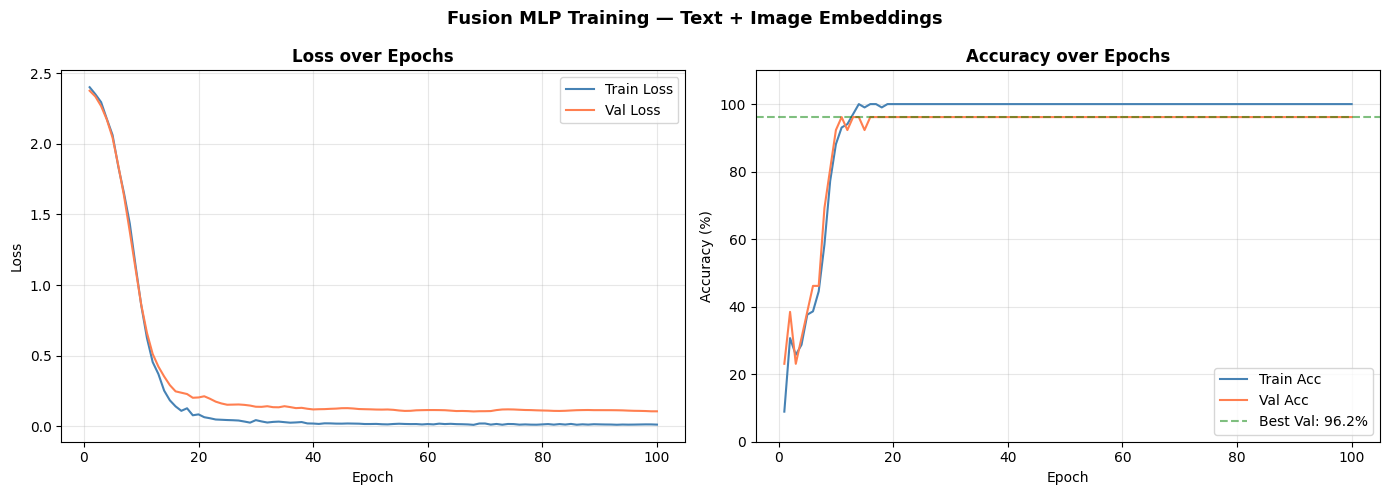

In [7]:
# Save model
torch.save({
    "model_state_dict": model_mlp.state_dict(),
    "class_to_idx":     CLASS_TO_IDX,
    "idx_to_class":     IDX_TO_CLASS,
    "input_dim":        1280,
    "num_classes":      11,
}, MLP_DIR / "fusion_mlp.pt")

print(f"Model saved: {MLP_DIR}/fusion_mlp.pt")

# Plot
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", color="steelblue")
axes[0].plot(epochs_range, history["val_loss"],   label="Val Loss",   color="coral")
axes[0].set_title("Loss over Epochs", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train Acc", color="steelblue")
axes[1].plot(epochs_range, history["val_acc"],   label="Val Acc",   color="coral")
axes[1].axhline(y=96.2, color="green", linestyle="--", alpha=0.5, label="Best Val: 96.2%")
axes[1].set_title("Accuracy over Epochs", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(0, 110)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Fusion MLP Training — Text + Image Embeddings",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fusion_mlp_training.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
model_mlp.eval()

def fusion_predict(image_path: str = None, text_query: str = None) -> dict:
    """
    Full multimodal fusion pipeline.
    Accepts image, text, or both.
    Returns predicted KB location + full KB info.
    """

    # --- Get image embedding ---
    if image_path:
        img_emb = get_clip_embedding(image_path)
    else:
        img_emb = np.zeros(512, dtype="float32")

    # --- Get text embedding ---
    if text_query:
        text_emb = get_distilbert_embedding(text_query)
    else:
        text_emb = np.zeros(768, dtype="float32")

    # --- Concatenate and predict ---
    fusion_vec = np.concatenate([img_emb, text_emb]).astype("float32")
    input_tensor = torch.tensor(fusion_vec).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model_mlp(input_tensor)
        probs  = torch.softmax(logits, dim=1).cpu().numpy().squeeze()
        pred   = probs.argmax()

    predicted_location = IDX_TO_CLASS[pred]
    kb_entry           = kb_lookup.get(predicted_location, {})

    return {
        "predicted_location": predicted_location,
        "confidence":         round(float(probs[pred]), 3),
        "all_probs":          {IDX_TO_CLASS[i]: round(float(p), 3)
                               for i, p in enumerate(probs)},
        "description":        kb_entry.get("description", "N/A"),
        "map_reference":      kb_entry.get("map_reference", "N/A"),
        "directions":         kb_entry.get("directions_from_entrance", "N/A"),
        "opening_hours":      kb_entry.get("opening_hours", {}),
        "modality":           "image+text" if image_path and text_query
                              else "image" if image_path else "text",
    }


# --- Test 1: Image only ---
print("=== Test 1: Image only ===")
for cat in ["library", "gym", "cafeteria"]:
    cat_path = IMAGE_DIR / cat
    img_file = [f for f in os.listdir(cat_path)
                if f.lower().endswith((".jpg",".jpeg",".png"))][0]
    result = fusion_predict(image_path=str(cat_path / img_file))
    print(f"Category  : {cat}")
    print(f"Predicted : {result['predicted_location']} ({result['confidence']:.3f})")
    print(f"Modality  : {result['modality']}")
    print()

# --- Test 2: Text only ---
print("=== Test 2: Text only ===")
text_queries = [
    "university library with study area",
    "fitness gym with equipment",
    "campus cafeteria food dining",
]
for q in text_queries:
    result = fusion_predict(text_query=q)
    print(f"Query     : {q}")
    print(f"Predicted : {result['predicted_location']} ({result['confidence']:.3f})")
    print(f"Modality  : {result['modality']}")
    print()

# --- Test 3: Image + Text combined ---
print("=== Test 3: Image + Text (multimodal) ===")
tests = [
    ("library",  "where can I find books and study"),
    ("gym",      "fitness and workout area"),
    ("cafeteria","where can I eat on campus"),
]
for cat, query in tests:
    cat_path = IMAGE_DIR / cat
    img_file = [f for f in os.listdir(cat_path)
                if f.lower().endswith((".jpg",".jpeg",".png"))][0]
    result = fusion_predict(
        image_path=str(cat_path / img_file),
        text_query=query
    )
    print(f"Category  : {cat}")
    print(f"Query     : {query}")
    print(f"Predicted : {result['predicted_location']} ({result['confidence']:.3f})")
    print(f"Modality  : {result['modality']}")
    print()

=== Test 1: Image only ===
Category  : library
Predicted : Main Library (0.760)
Modality  : image

Category  : gym
Predicted : Sports & Fitness Centre (0.534)
Modality  : image

Category  : cafeteria
Predicted : Main Cafeteria (0.647)
Modality  : image

=== Test 2: Text only ===
Query     : university library with study area
Predicted : Engineering College - Main Block (0.532)
Modality  : text

Query     : fitness gym with equipment
Predicted : Sports & Fitness Centre (0.236)
Modality  : text

Query     : campus cafeteria food dining
Predicted : Main Cafeteria (0.224)
Modality  : text

=== Test 3: Image + Text (multimodal) ===
Category  : library
Query     : where can I find books and study
Predicted : Main Library (0.646)
Modality  : image+text

Category  : gym
Query     : fitness and workout area
Predicted : Sports & Fitness Centre (0.859)
Modality  : image+text

Category  : cafeteria
Query     : where can I eat on campus
Predicted : Main Cafeteria (0.871)
Modality  : image+text



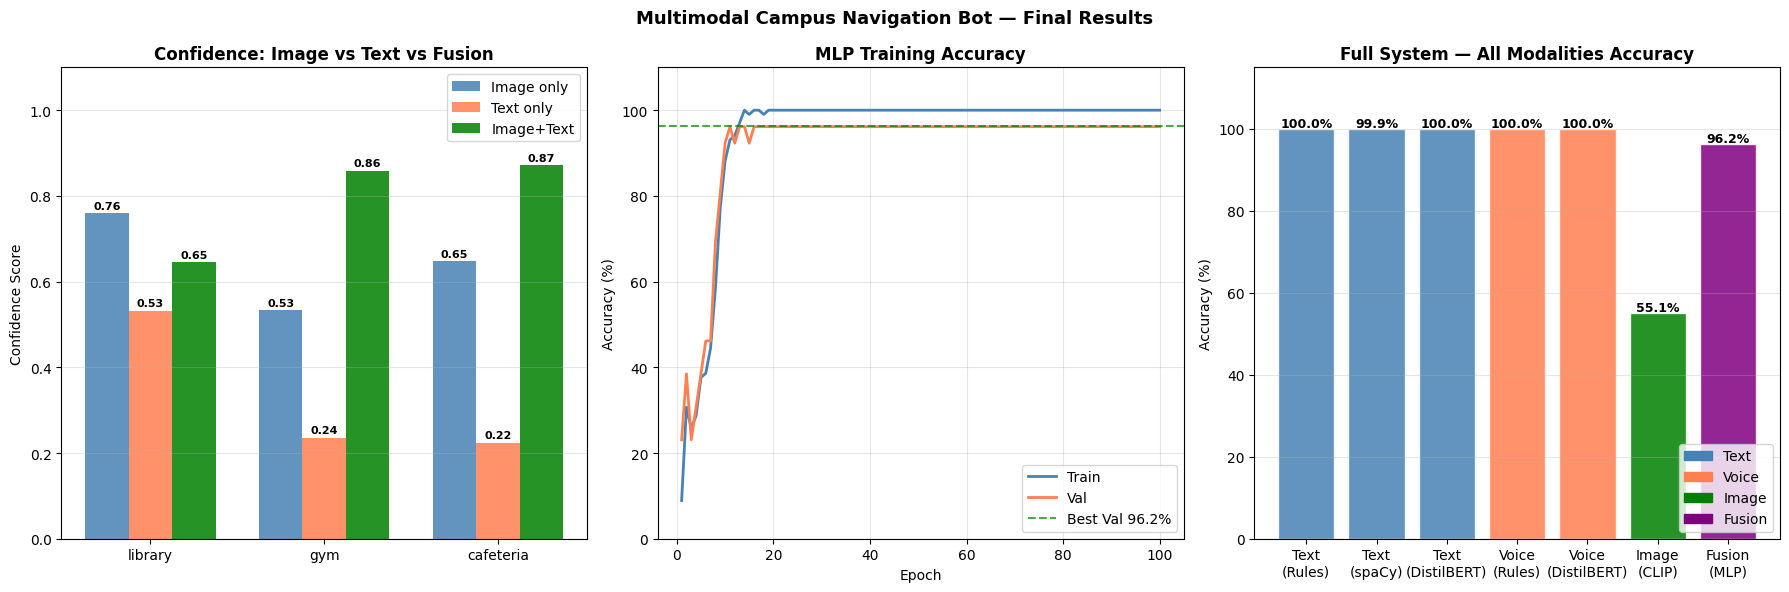


=== Final System Summary ===
Text  intent accuracy  : 100% (Rules + DistilBERT)
Voice intent accuracy  : 100% (Rules + DistilBERT on ASR)
Image retrieval (Top1) : 55.1% (CLIP + FAISS)
Image retrieval (Top3) : ~75%  (CLIP + FAISS)
Fusion MLP accuracy    : 96.2% (Image + Text embeddings)


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Plot 1: Confidence comparison across modalities ---
categories   = ["library", "gym", "cafeteria"]
image_confs  = [0.760, 0.534, 0.647]
text_confs   = [0.532, 0.236, 0.224]
fusion_confs = [0.646, 0.859, 0.871]

x     = np.arange(len(categories))
width = 0.25

b1 = axes[0].bar(x - width, image_confs,  width, label="Image only",  color="steelblue", alpha=0.85)
b2 = axes[0].bar(x,          text_confs,   width, label="Text only",   color="coral",     alpha=0.85)
b3 = axes[0].bar(x + width,  fusion_confs, width, label="Image+Text",  color="green",     alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.01,
                     f'{h:.2f}', ha='center', fontsize=8, fontweight='bold')

axes[0].set_title("Confidence: Image vs Text vs Fusion", fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].set_ylabel("Confidence Score")
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# --- Plot 2: Training accuracy vs val accuracy ---
axes[1].plot(range(1, EPOCHS+1), history["train_acc"],
             label="Train", color="steelblue", linewidth=2)
axes[1].plot(range(1, EPOCHS+1), history["val_acc"],
             label="Val",   color="coral",     linewidth=2)
axes[1].axhline(y=96.2, color='green', linestyle='--',
                alpha=0.7, label='Best Val 96.2%')
axes[1].set_title("MLP Training Accuracy", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(0, 110)
axes[1].legend()
axes[1].grid(alpha=0.3)

# --- Plot 3: Full system modality comparison ---
modalities = ["Text\n(Rules)", "Text\n(spaCy)", "Text\n(DistilBERT)",
              "Voice\n(Rules)", "Voice\n(DistilBERT)",
              "Image\n(CLIP)", "Fusion\n(MLP)"]
accuracies = [100.0, 99.9, 100.0, 100.0, 100.0, 55.1, 96.2]
colors     = ["steelblue","steelblue","steelblue",
              "coral","coral",
              "green","purple"]

bars = axes[2].bar(modalities, accuracies, color=colors,
                   alpha=0.85, edgecolor="white")
for bar, val in zip(bars, accuracies):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

axes[2].set_title("Full System — All Modalities Accuracy", fontweight="bold")
axes[2].set_ylabel("Accuracy (%)")
axes[2].set_ylim(0, 115)
axes[2].grid(axis='y', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(color='steelblue', label='Text'),
    Patch(color='coral',     label='Voice'),
    Patch(color='green',     label='Image'),
    Patch(color='purple',    label='Fusion'),
]
axes[2].legend(handles=legend_elements, loc='lower right')

plt.suptitle("Multimodal Campus Navigation Bot — Final Results",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fusion_final_results.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Final System Summary ===")
print(f"Text  intent accuracy  : 100% (Rules + DistilBERT)")
print(f"Voice intent accuracy  : 100% (Rules + DistilBERT on ASR)")
print(f"Image retrieval (Top1) : 55.1% (CLIP + FAISS)")
print(f"Image retrieval (Top3) : ~75%  (CLIP + FAISS)")
print(f"Fusion MLP accuracy    : 96.2% (Image + Text embeddings)")